# Lumpyspace: Live Training Monitor
This notebook provides real-time visualization of the PINN training progress by reading the live CSV logs generated by `src/training/run.py`.

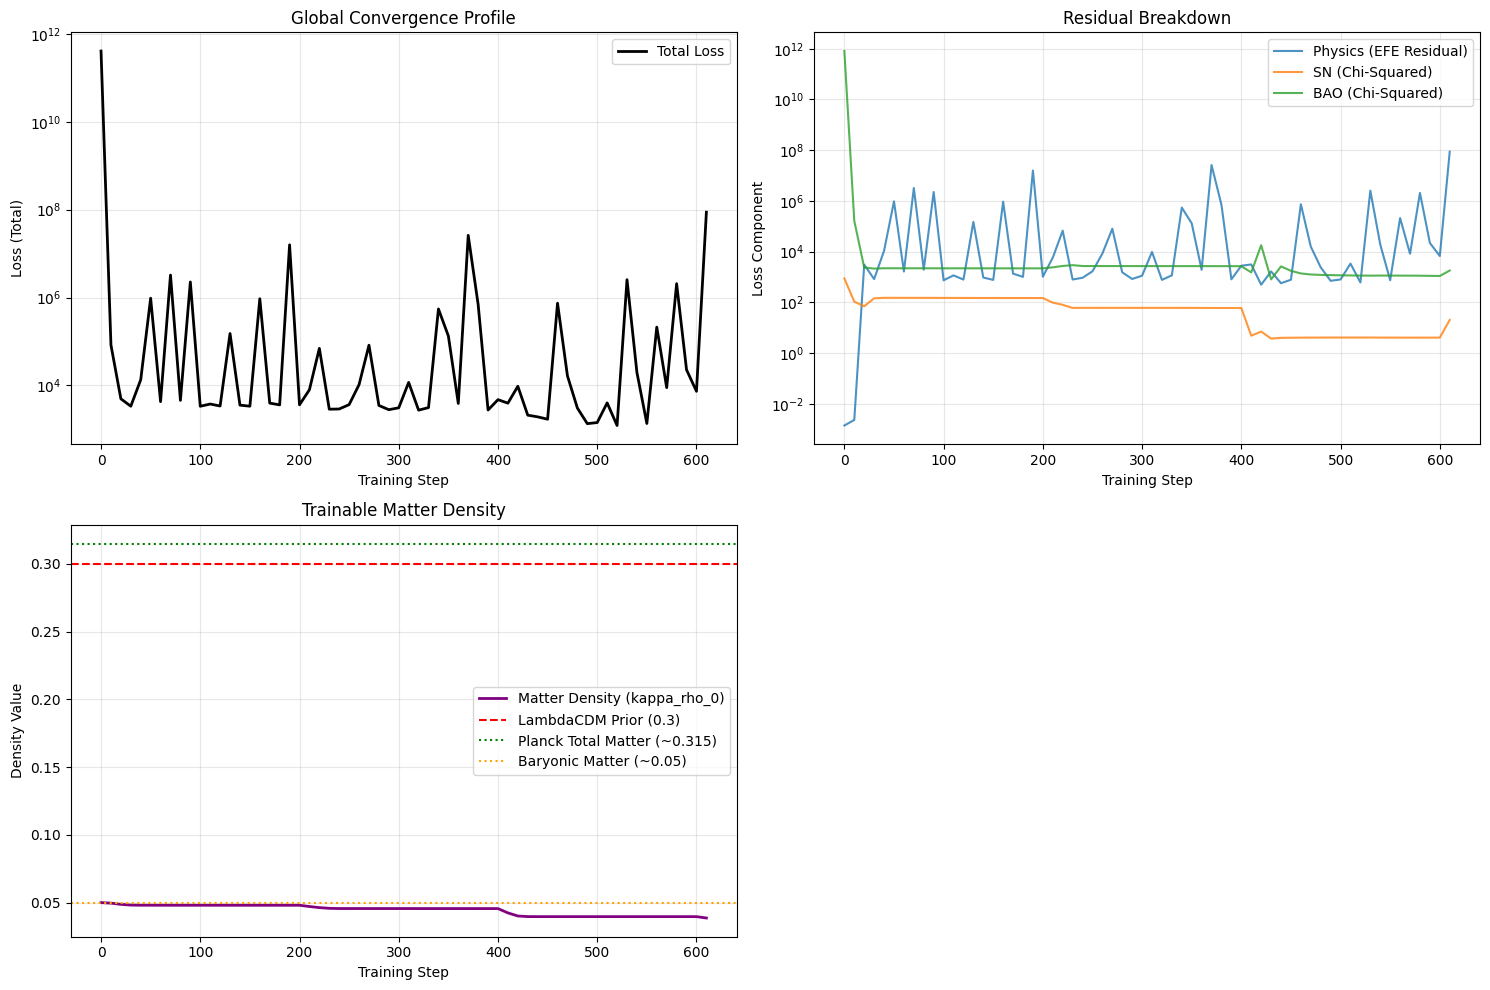

Last Update: 16:28:00 | Steps: 610 | Current Loss: 8.734e+07
Physics Loss: 8.733e+07 | SN Loss: 2.041e+01 | BAO Loss: 1.809e+03
Kappa Rho 0: 3.866e-02


In [ ]:
import os
import time

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import clear_output

# Path to the production logs
log_path = "../logs/training_metrics.csv"


def monitor_convergence():
  while True:
    if not os.path.exists(log_path):
      clear_output(wait=True)
      print(f"Waiting for log file: {log_path}...")
      time.sleep(5)
      continue

    try:
      df = pd.read_csv(log_path)
      if len(df) > 1:
        clear_output(wait=True)
        fig, ax = plt.subplots(2, 2, figsize=(15, 10))

        # Top-left: Plot Total Loss (Log Scale)
        ax[0, 0].plot(
          df["step"],
          df["loss"].astype(float),
          label="Total Loss",
          color="black",
          linewidth=1,
        )
        ax[0, 0].set_yscale("log")
        ax[0, 0].set_xlabel("Training Step")
        ax[0, 0].set_ylabel("Loss (Total)")
        ax[0, 0].set_title("Global Convergence Profile")
        ax[0, 0].grid(True, which="both", ls="-", alpha=0.3)
        ax[0, 0].legend()

        # Top-right: Plot Components
        ax[0, 1].plot(
          df["step"],
          df["l_phys"].astype(float),
          label="Physics (EFE Residual)",
          alpha=0.8,
        )
        ax[0, 1].plot(
          df["step"],
          df["l_sn"].astype(float),
          label="SN (Chi-Squared)",
          alpha=0.8,
        )
        ax[0, 1].plot(
          df["step"],
          df["l_bao"].astype(float),
          label="BAO (Chi-Squared)",
          alpha=0.8,
        )
        ax[0, 1].set_yscale("log")
        ax[0, 1].set_xlabel("Training Step")
        ax[0, 1].set_ylabel("Loss Component")
        ax[0, 1].set_title("Residual Breakdown")
        ax[0, 1].grid(True, which="both", ls="-", alpha=0.3)
        ax[0, 1].legend()

        # Bottom-Left: Plot Trainable Matter Density
        ax[1, 0].plot(
          df["step"],
          df["kappa_rho_0"].astype(float) / 3.0,
          label="Matter Density (kappa_rho_0)",
          color="purple",
          linewidth=2,
        )
        ax[1, 0].axhline(y=0.3, color="r", linestyle="--",
                         label="LambdaCDM Prior (0.3)")
        ax[1, 0].axhline(y=0.315, color="green", linestyle=":",
                         label="Planck Total Matter (~0.315)")
        ax[1, 0].axhline(y=0.05, color="orange", linestyle=":",
                         label="Baryonic Matter (~0.05)")
        ax[1, 0].set_xlabel("Training Step")
        ax[1, 0].set_ylabel("Density Value")
        ax[1, 0].set_title("Trainable Matter Density")
        ax[1, 0].grid(True, which="both", ls="-", alpha=0.3)
        ax[1, 0].legend()

        # Bottom-right: empty
        ax[1, 1].axis('off')

        plt.tight_layout()
        plt.show()

        print(
          f"Last Update: {time.strftime('%H:%M:%S')} | "
          f"Steps: {df['step'].iloc[-1]} | "
          f"Current Loss: {df['loss'].iloc[-1]:.3e}\n"
          f"Physics Loss: {df['l_phys'].iloc[-1]:.3e} | "
          f"SN Loss: {df['l_sn'].iloc[-1]:.3e} | "
          f"BAO Loss: {df['l_bao'].iloc[-1]:.3e}\n"
          f"Kappa Rho 0: {(df['kappa_rho_0'].iloc[-1] / 3.0):.3e}"
        )
    except Exception as e:
      print(f"Error reading logs: {e}")

    time.sleep(10)  # Refresh every 10 seconds to reduce IO overhead


monitor_convergence()

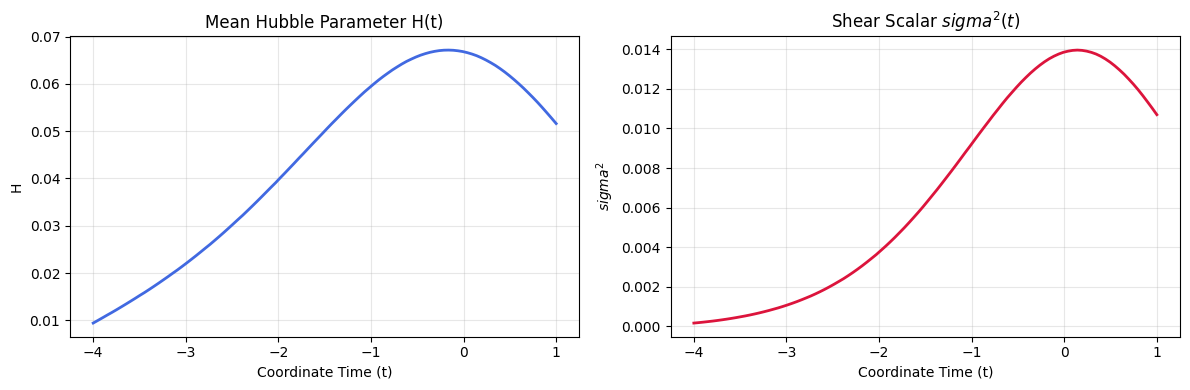

In [ ]:
import jax
import jax.numpy as jnp
from jax import jacfwd, vmap
import matplotlib.pyplot as plt
import equinox as eqx
import sys

# Ensure notebook can find the src module
sys.path.append(os.path.abspath('..'))
#sys.path.insert(0, '/home/dma/dev/lumpyspace')

from src.core.metric import MetricNN

# 1. Load the checkpoint
checkpoint_path = "../checkpoints/pinn_metric.eqx"
key = jax.random.PRNGKey(0)
model_skeleton = MetricNN(key) # Blank structure
# Hydrate the model with your trained weights
model = eqx.tree_deserialise_leaves(checkpoint_path, model_skeleton)

# 2. The Extraction Math
def extract_cosmology(model, t_eval):
    def compute_kinematics(t):
        coords = jnp.array([t, 0.0, 0.0, 0.0])
        g = model(coords)
        
        # Spatial Metric
        g_spatial = g[1:4, 1:4]
        g_spatial_inv = jnp.linalg.inv(g_spatial)
        
        # d/dt g_ij (Derivative wrt coordinate time)
        dg_dt = jacfwd(model)(coords)[:, :, 0]
        dg_spatial_dt = dg_dt[1:4, 1:4]
        
        # Lapse function alpha
        alpha = jnp.sqrt(-g[0, 0])
        
        # Expansion & Hubble Tensors
        theta_ij = (1.0 / (2.0 * alpha)) * dg_spatial_dt
        h_tensor = jnp.einsum('ik,kj->ij', g_spatial_inv, theta_ij)
        
        h_mean = jnp.trace(h_tensor) / 3.0
        
        # Extract the directional expansion rates
        h_x, h_y, h_z = h_tensor[0,0], h_tensor[1,1], h_tensor[2,2]
        
        # Shear Tensor and Scalar
        sigma_tensor = h_tensor - h_mean * jnp.eye(3)
        sigma_sq = 0.5 * jnp.einsum('ij,ji->', sigma_tensor, sigma_tensor)
        
        return h_mean, sigma_sq, h_x, h_y, h_z
        
    return vmap(compute_kinematics)(t_eval)

# 3. Evaluate and Plot
t_eval = jnp.linspace(-4.0, 1.0, 100)

# Unpack all 5 variables
h_mean, sigma_sq, h_x, h_y, h_z = extract_cosmology(model, t_eval)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# --- LEFT CHART: Directional Expansion Rates ---
# Plot the mean as a solid thick black line
ax1.plot(t_eval, h_mean, color='black', linewidth=3, label='H_mean')

# Plot the directional components as dashed colored lines
ax1.plot(t_eval, h_x, color='red', linestyle='--', linewidth=2, label='H_x')
ax1.plot(t_eval, h_y, color='green', linestyle='--', linewidth=2, label='H_y')
ax1.plot(t_eval, h_z, color='blue', linestyle='--', linewidth=2, label='H_z')

ax1.set_xlabel('Coordinate Time (t)')
ax1.set_ylabel('Hubble Parameter (H)')
ax1.set_title('Directional Expansion Rates H(t)')
ax1.grid(True, alpha=0.3)
ax1.legend()

# --- RIGHT CHART: Shear Scalar ---
ax2.plot(t_eval, sigma_sq, color='crimson', linewidth=2)
ax2.set_xlabel('Coordinate Time (t)')
ax2.set_ylabel(r'Shear Scalar $\sigma^2$')
ax2.set_title(r'Shear Scalar $\sigma^2(t)$')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

